## Project Objective
The goal of this notebook is to analyze telecommunications customer data to identify key drivers of service cancellation (Churn). The second part of this notebook evaluates the performance of our winning machine learning model (Logistic Regression with SMOTE) trained and serialized in the data pipeline.

**Core Business Questions:**
1. At what point in the customer lifecycle does churn peak?
2. Which services foster loyalty, and which act as churn drivers?
3. How effectively does our production model identify at-risk customers?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Set professional plotting style for business presentations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

import warnings
warnings.filterwarnings('ignore')

In [2]:
def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """Loads raw data and performs basic cleaning operations."""
    df = pd.read_csv(filepath)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df.dropna(subset=['TotalCharges'], inplace=True)
    df.drop(columns=["customerID"], inplace=True)
    return df

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Derives new predictive features from existing columns."""
    df_eng = df.copy()
    service_columns = [
        'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    df_eng['AdditionalServices'] = (df_eng[service_columns] == 'Yes').sum(axis=1)
    df_eng['ChargePer_TenureLength'] = df_eng['MonthlyCharges'] / (df_eng['tenure'] + 1)
    df_eng['Churn'] = df_eng['Churn'].map({'Yes': 1, 'No': 0})
    return df_eng

# Load and prepare data for exploratory analysis
df = load_and_clean_data('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = engineer_features(df)

## 1. Exploratory Data Analysis (EDA)
Let's investigate the relationship between our key numerical features and the target variable (Churn).

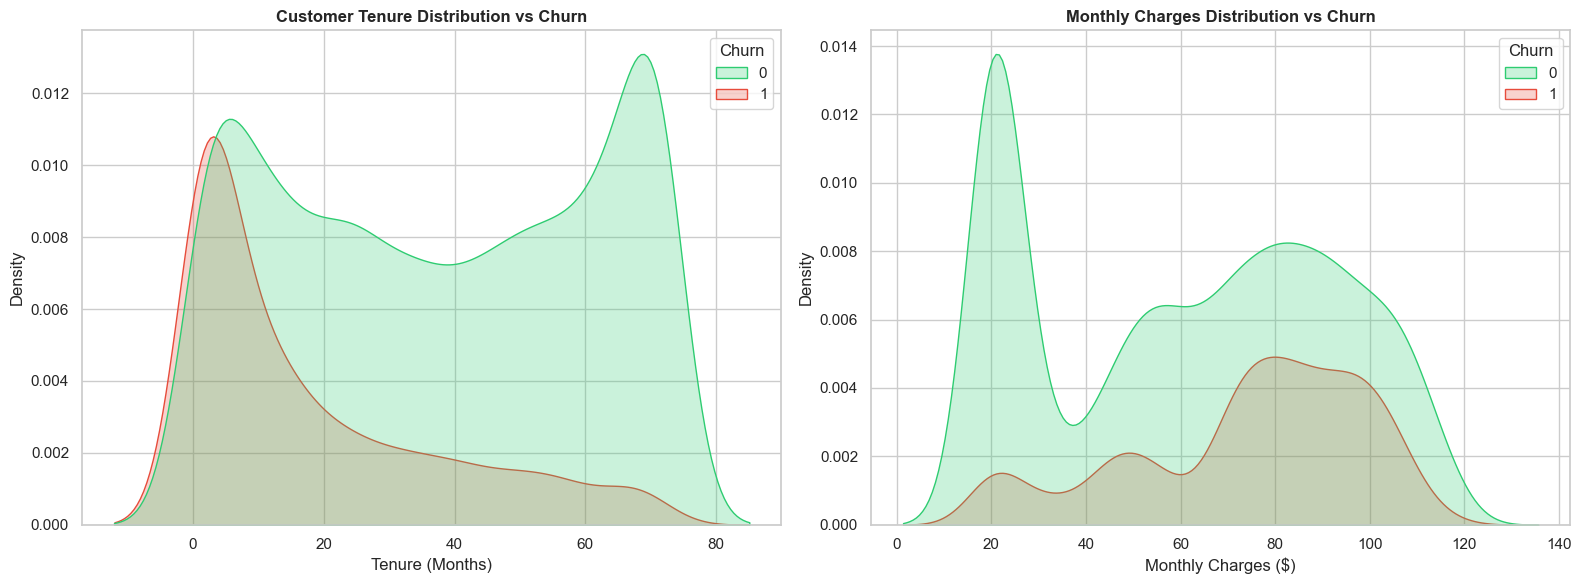

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Customer Tenure
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, ax=ax[0], palette=['#2ecc71', '#e74c3c'])
ax[0].set_title('Customer Tenure Distribution vs Churn', fontweight='bold')
ax[0].set_xlabel('Tenure (Months)')
ax[0].set_ylabel('Density')

# Plot 2: Monthly Charges
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, ax=ax[1], palette=['#2ecc71', '#e74c3c'])
ax[1].set_title('Monthly Charges Distribution vs Churn', fontweight='bold')
ax[1].set_xlabel('Monthly Charges ($)')
ax[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

> **Key Business Takeaways:**
> * **Tenure Risk:** The highest risk of churn occurs within the first 5 months of the customer lifecycle. If a customer remains with the company for over a year, the probability of churn drops significantly.
> * **Price Sensitivity:** Churning customers (red distribution) are heavily concentrated in the high-monthly-charge bracket ($70-$110). Conversely, customers with low monthly bills (~$20) exhibit extremely high loyalty.

## 2. Machine Learning Model Evaluation
Here, we load our best performing model (Logistic Regression optimized via GridSearch) and evaluate it on the hold-out test set to ensure there is no data leakage.

In [4]:
# Recreate the exact train/test split to isolate the unseen test data
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Load the production-ready pipeline from disk
try:
    model = joblib.load('churn_logisticregression_pipeline.pkl')
    print("Successfully loaded model pipeline from disk.")
except FileNotFoundError:
    print("Model file not found. Please ensure train.py was executed first.")

# Generate predictions and probabilities for ROC
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

Successfully loaded model pipeline from disk.


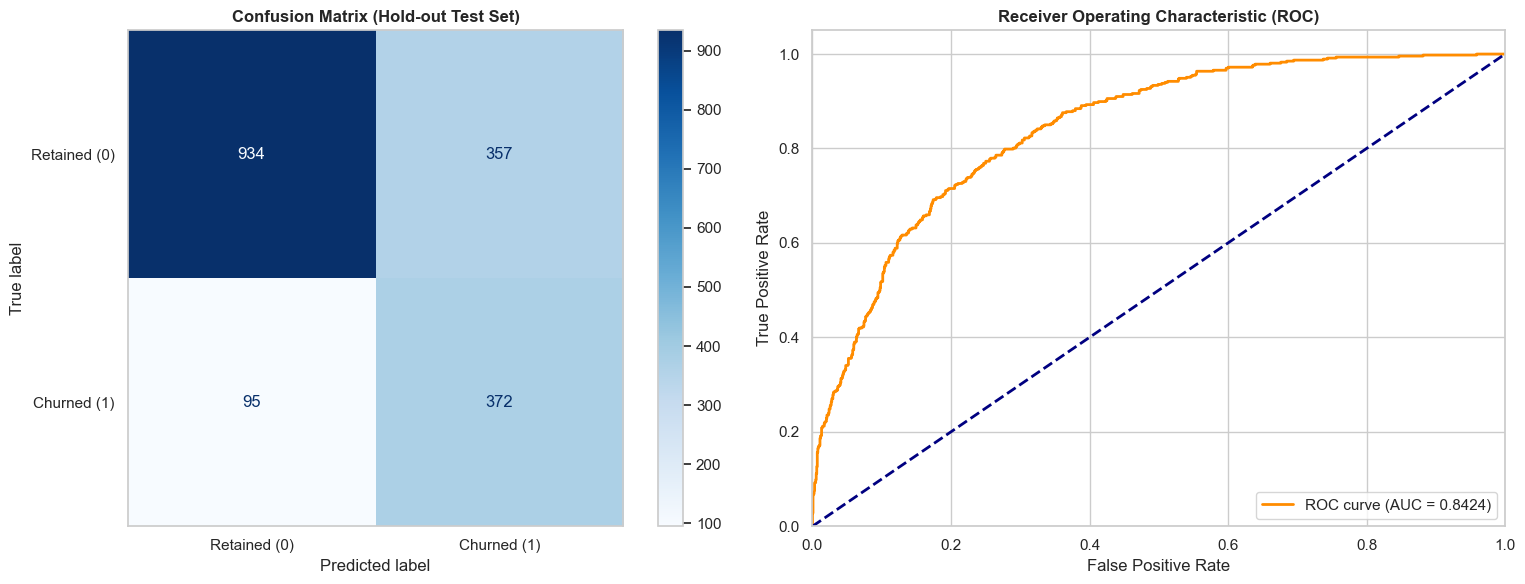

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained (0)', 'Churned (1)'])
disp.plot(cmap='Blues', ax=ax[0], values_format='d')
ax[0].set_title('Confusion Matrix (Hold-out Test Set)', fontweight='bold')
ax[0].grid(False) # Disable grid lines for a cleaner matrix look

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 3. What Drives Churn? (Model Interpretability)
One of the primary advantages of Logistic Regression is its high interpretability. By examining the model's coefficients, we can definitively see which features drive customers away and which keep them loyal.

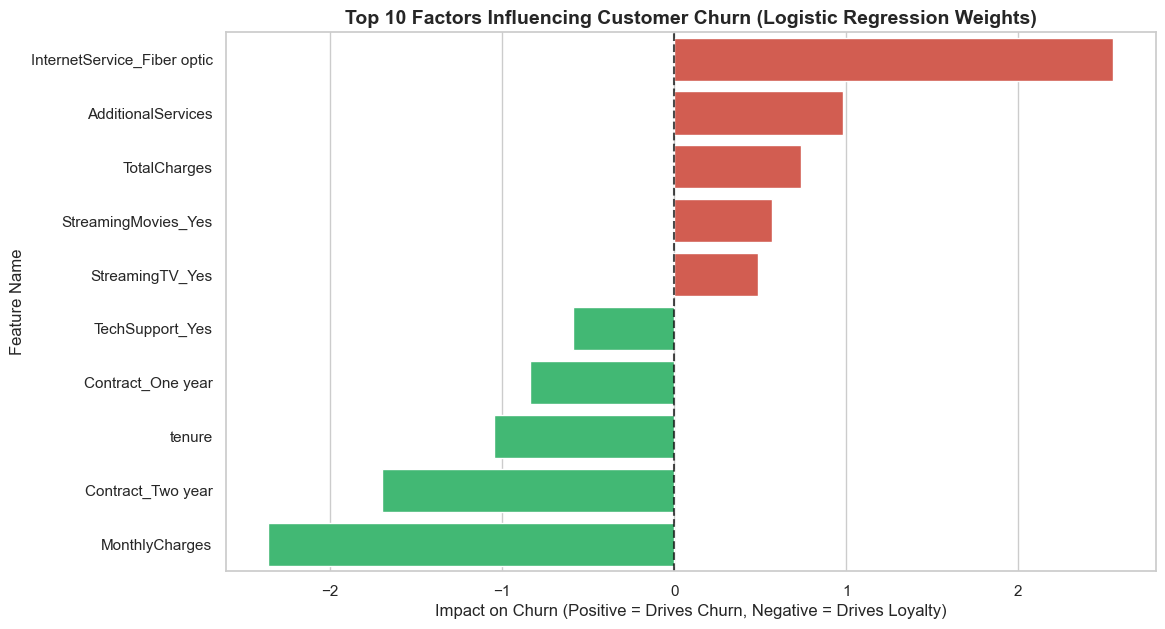

In [6]:
# Extract processing steps from the imblearn pipeline
preprocessor = model.named_steps['preprocessor']
classifier = model.named_steps['classifier']

# Reconstruct feature names post-transformation (StandardScaler & OneHotEncoder)
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out().tolist()
all_features = num_features + cat_features

# Extract logistic regression coefficients (weights)
coefficients = classifier.coef_[0]

# Create a DataFrame for easy sorting and plotting
feat_imp = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients})
feat_imp = feat_imp.sort_values(by='Coefficient', ascending=False)

# Select Top 5 churn drivers (positive) and Top 5 retention drivers (negative)
top_positive = feat_imp.head(5)
top_negative = feat_imp.tail(5)
plot_data = pd.concat([top_positive, top_negative])

# Visualize the coefficients
plt.figure(figsize=(12, 7))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in plot_data['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=plot_data, palette=colors)

plt.title('Top 10 Factors Influencing Customer Churn (Logistic Regression Weights)', fontweight='bold', fontsize=14)
plt.xlabel('Impact on Churn (Positive = Drives Churn, Negative = Drives Loyalty)')
plt.ylabel('Feature Name')
plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.show()